<a href="https://colab.research.google.com/github/kanaka-22/codealpha_tasks/blob/main/Task3_Sales_Prediction_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder

***Load Dataset***

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Advertising.csv")
print(data.head())
print(data.info())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


***Data Cleaning***

In [4]:
# Check missing values
print(data.isnull().sum())

# The original code attempted to convert a 'Date' column which does not exist in this dataset.
# Therefore, the lines below are commented out or removed.
# data['Date'] = pd.to_datetime(data['Date'])
# data['Month'] = data['Date'].dt.month
# data['Day'] = data['Date'].dt.day

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


***Data Visualization (EDA)***

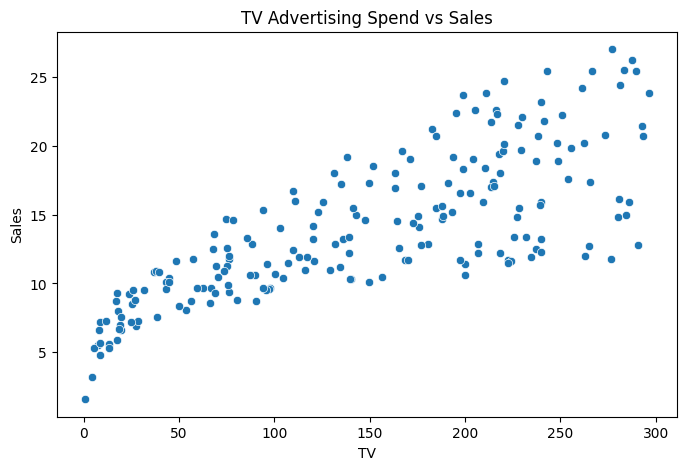

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='TV', y='Sales', data=data)
plt.title("TV Advertising Spend vs Sales")
plt.show()

# If you intended to plot total advertising spend, you would first create a new column like this:
# data['Advertising_Spend'] = data['TV'] + data['Radio'] + data['Newspaper']
# sns.scatterplot(x='Advertising_Spend', y='Sales', data=data)
# plt.title("Total Advertising Spend vs Sales")
# plt.show()

***Feature Encoding***

In [8]:
# data_encoded = pd.get_dummies(data, columns=['Platform', 'Target_Segment'], drop_first=True)

***Feature Selection***

In [17]:
X = data.drop(['Sales', 'Unnamed: 0'], axis=1)
y = data['Sales']

# Display the feature columns used for training the model
print("Features used for model training:", X.columns.tolist())

Features used for model training: ['TV', 'Radio', 'Newspaper']


***Train-Test Split***

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

***Train Regression Model***

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

***Predictions***

In [20]:
y_pred = model.predict(X_test)

***Model Evaluation***

In [21]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.4607567168117603
R2 Score: 0.899438024100912


***Feature Importance***

In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
}).sort_values(by='Impact', ascending=False)

print(coefficients)

     Feature    Impact
1      Radio  0.189195
0         TV  0.044730
2  Newspaper  0.002761


***Forecast Future Sales***

In [27]:
future_data = pd.DataFrame({
    'TV': [200.0], # Example TV advertising spend
    'Radio': [40.0], # Example Radio advertising spend
    'Newspaper': [10.0] # Example Newspaper advertising spend
})

prediction = model.predict(future_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 19.520384144654628
